# 5.2 Soft matte and spill suppression

5.2 Soft matte and spill suppression:
(a) chroma-distance distributions for backing / partial-alpha / foreground
(b) continuous alpha, composite, fraction of fractional-alpha pixels
(c) spill suppression, residual green excess over fractional-alpha pixels
(d) naive vs soft matte comparison (MAD of alpha maps and gradient fields)

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import (to_ycbcr, estimate_key_colour, key_soft, key_naive_rgb,
                      suppress_spill, composite, grad_error, load_frame_window)

In [4]:
ROOT = Path.cwd().parents[1]
# Frame 24 of the 48-frame window (see starter.load_frame_window),
# decoded on the fly from the source clip -- no extracted frame files
# are stored in the repo.
CLIP = ROOT / "Images/input/P5/green_screen_clip.mp4"
frames_48 = load_frame_window(CLIP, n_frames=48)
frame = frames_48[24]
H, W, _ = frame.shape
key_cbcr = estimate_key_colour(frame)
print(f"estimated key (Cb,Cr) = {key_cbcr}")

estimated key (Cb,Cr) = [86.141612 71.510436]


In [5]:
ycc = to_ycbcr(frame)
Cb, Cr = ycc[..., 1], ycc[..., 2]
dist = np.sqrt((Cb - key_cbcr[0]) ** 2 + (Cr - key_cbcr[1]) ** 2)

In [6]:
# (a) chroma distance distributions: backing / partial / foreground

In [7]:
backing_dist = dist[0:55, :].flatten()
face_dist = dist[220:340, 400:550].flatten()
jacket_dist = dist[450:600, 500:800].flatten()
fg_dist = np.concatenate([face_dist, jacket_dist])
hair_dist = dist[90:170, 370:530].flatten()

In [8]:
print(f"\nbacking:    n={len(backing_dist):6d}  mean={backing_dist.mean():6.2f}  "
      f"p1={np.percentile(backing_dist,1):5.2f}  p99={np.percentile(backing_dist,99):5.2f}")
print(f"foreground: n={len(fg_dist):6d}  mean={fg_dist.mean():6.2f}  "
      f"p1={np.percentile(fg_dist,1):5.2f}  p99={np.percentile(fg_dist,99):5.2f}")
print(f"hair-edge:  n={len(hair_dist):6d}  mean={hair_dist.mean():6.2f}  "
      f"p1={np.percentile(hair_dist,1):5.2f}  p99={np.percentile(hair_dist,99):5.2f}")


backing:    n= 70400  mean=  5.61  p1= 2.34  p99= 8.63
foreground: n= 63000  mean= 74.04  p1=43.79  p99=90.80
hair-edge:  n= 12800  mean= 39.79  p1= 1.39  p99=77.99


In [9]:
separates = np.percentile(backing_dist, 99) < np.percentile(fg_dist, 1)
print(f"\nbacking p99 ({np.percentile(backing_dist,99):.2f}) < "
      f"foreground p1 ({np.percentile(fg_dist,1):.2f})? {separates}")


backing p99 (8.63) < foreground p1 (43.79)? True


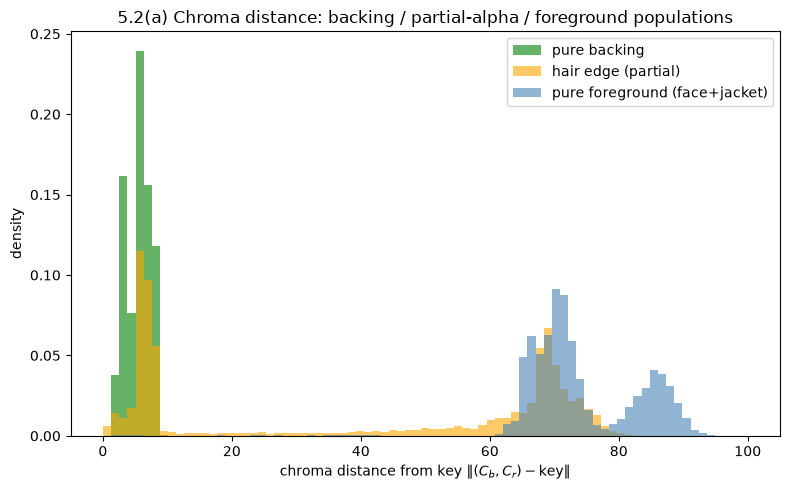

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 100, 80)
ax.hist(backing_dist, bins=bins, alpha=0.6, label="pure backing", color="green", density=True)
ax.hist(hair_dist, bins=bins, alpha=0.6, label="hair edge (partial)", color="orange", density=True)
ax.hist(fg_dist, bins=bins, alpha=0.6, label="pure foreground (face+jacket)", color="steelblue",
        density=True)
ax.set_xlabel("chroma distance from key $\\|(C_b,C_r)-\\mathrm{key}\\|$")
ax.set_ylabel("density")
ax.set_title("5.2(a) Chroma distance: backing / partial-alpha / foreground populations")
ax.legend()
fig.tight_layout()
plt.show()

In [11]:
# thresholds chosen from the data above: t_in just above the backing p99,
# t_out at the foreground p1 (both populations' tails, giving margin)
T_IN = 12.0
T_OUT = 58.0
print(f"\nchosen t_in={T_IN} (backing p99={np.percentile(backing_dist,99):.1f}), "
      f"t_out={T_OUT} (foreground p1={np.percentile(fg_dist,1):.1f})")


chosen t_in=12.0 (backing p99=8.6), t_out=58.0 (foreground p1=43.8)


In [12]:
# (b) continuous alpha + composite

In [13]:
alpha = key_soft(frame, key_cbcr=key_cbcr, t_in=T_IN, t_out=T_OUT)
frac_mask = (alpha > 0) & (alpha < 1)
print(f"\nfraction of pixels with fractional alpha: {frac_mask.mean()*100:.2f}%")


fraction of pixels with fractional alpha: 1.06%


In [14]:
bg_plate = np.asarray(Image.open(ROOT / "Images/input/P5/pano.jpg"))
bg_h, bg_w, _ = bg_plate.shape
# static crop for this single-frame demo (panning handled in 5.3)
bg_crop = bg_plate[:H, :W] if bg_h >= H and bg_w >= W else np.array(
    Image.fromarray(bg_plate).resize((W, H)))

In [15]:
composite_nospill = composite(frame, bg_crop, alpha, spill=False)
composite_spill = composite(frame, bg_crop, alpha, spill=True, key_cbcr=key_cbcr,
                              spill_strength=3.0)

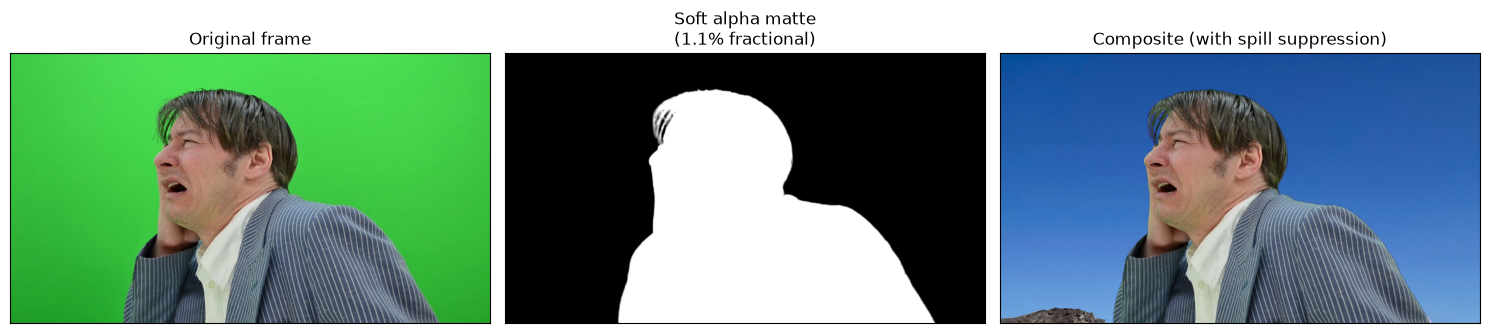

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
axes[0].imshow(frame)
axes[0].set_title("Original frame")
axes[1].imshow(alpha, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Soft alpha matte\n({frac_mask.mean()*100:.1f}% fractional)")
axes[2].imshow(composite_spill)
axes[2].set_title("Composite (with spill suppression)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

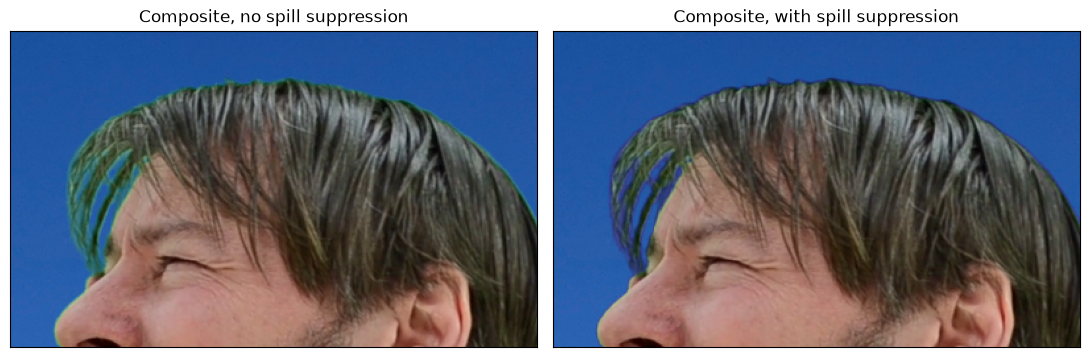

In [17]:
# with vs. without spill suppression, zoomed on the hair edge where spill is visible
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
zy0, zy1, zx0, zx1 = 60, 300, 350, 750
axes[0].imshow(composite_nospill[zy0:zy1, zx0:zx1])
axes[0].set_title("Composite, no spill suppression")
axes[1].imshow(composite_spill[zy0:zy1, zx0:zx1])
axes[1].set_title("Composite, with spill suppression")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

In [18]:
# (c) spill suppression: residual green excess over fractional-alpha pixels

In [19]:
def green_excess(rgb):
    rgb = rgb.astype(np.float64)
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    return np.maximum(G - np.maximum(R, B), 0.0)

In [20]:
excess_before = green_excess(frame)
excess_before_frac = excess_before[frac_mask]

# strength sweep: correction magnitude is strength * excess * (1-alpha), and
# at typical hair-edge alpha (~0.6) only ~40% of raw excess is removed at
# strength=1, so a sweep is needed to see how much strength is actually
# required to clear spill rather than assuming strength=1 suffices.
print("\nstrength sweep (residual green excess, fractional-alpha pixels only):")
SPILL_STRENGTH = 3.0
for s in (1.0, 2.0, SPILL_STRENGTH, 5.0):
    d = suppress_spill(frame, alpha, strength=s, key_cbcr=key_cbcr)
    e = green_excess(d)[frac_mask]
    print(f"  strength={s:.1f}: mean residual excess = {e.mean():6.2f} "
          f"({100*(1-e.mean()/excess_before_frac.mean()):.1f}% reduction)")


strength sweep (residual green excess, fractional-alpha pixels only):
  strength=1.0: mean residual excess =  22.97 (60.4% reduction)
  strength=2.0: mean residual excess =   8.77 (84.9% reduction)
  strength=3.0: mean residual excess =   5.17 (91.1% reduction)
  strength=5.0: mean residual excess =   2.74 (95.3% reduction)


In [21]:
despilled = suppress_spill(frame, alpha, strength=SPILL_STRENGTH, key_cbcr=key_cbcr)
excess_after_frac = green_excess(despilled)[frac_mask]
print(f"\nchosen strength={SPILL_STRENGTH}: before={excess_before_frac.mean():.2f}  "
      f"after={excess_after_frac.mean():.2f}  "
      f"({100*(1-excess_after_frac.mean()/excess_before_frac.mean()):.1f}% reduction)")


chosen strength=3.0: before=57.93  after=5.17  (91.1% reduction)


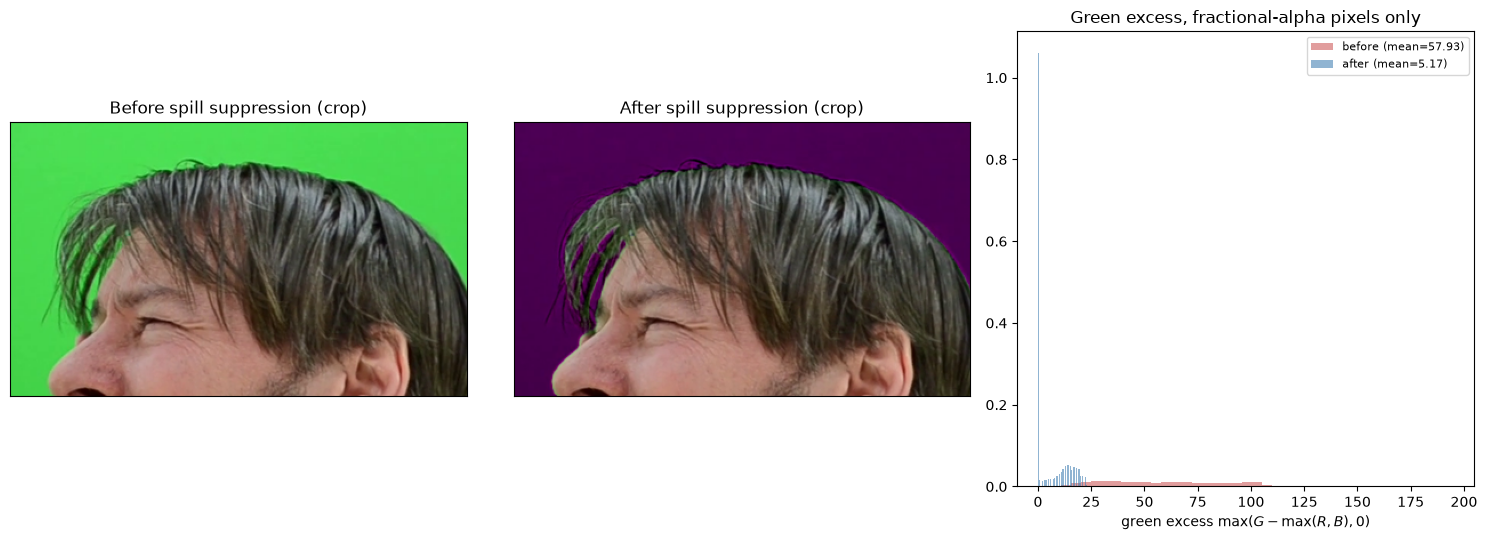

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
crop_y0, crop_y1, crop_x0, crop_x1 = 60, 300, 350, 750
axes[0].imshow(frame[crop_y0:crop_y1, crop_x0:crop_x1])
axes[0].set_title("Before spill suppression (crop)")
axes[1].imshow(despilled[crop_y0:crop_y1, crop_x0:crop_x1])
axes[1].set_title("After spill suppression (crop)")
axes[2].hist(excess_before_frac, bins=40, alpha=0.6, label=f"before (mean={excess_before_frac.mean():.2f})",
             color="indianred", density=True)
axes[2].hist(excess_after_frac, bins=40, alpha=0.6, label=f"after (mean={excess_after_frac.mean():.2f})",
             color="steelblue", density=True)
axes[2].set_xlabel("green excess $\\max(G-\\max(R,B),0)$")
axes[2].set_title("Green excess, fractional-alpha pixels only")
axes[2].legend(fontsize=8)
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

In [23]:
# (d) naive vs soft matte comparison

In [24]:
alpha_naive = key_naive_rgb(frame, thresh=60)
mad_alpha = float(np.mean(np.abs(alpha_naive - alpha)))
gradient_mad = grad_error(alpha_naive * 255, alpha * 255) * 1000 / alpha.size  # per-pixel scale
print(f"\nMAD(alpha_naive, alpha_soft) = {mad_alpha:.4f}")
print(f"grad_error(alpha_naive, alpha_soft) [raw sad-of-gradients/1000] = "
      f"{grad_error(alpha_naive*255, alpha*255):.2f}")


MAD(alpha_naive, alpha_soft) = 0.0026
grad_error(alpha_naive, alpha_soft) [raw sad-of-gradients/1000] = 228.32


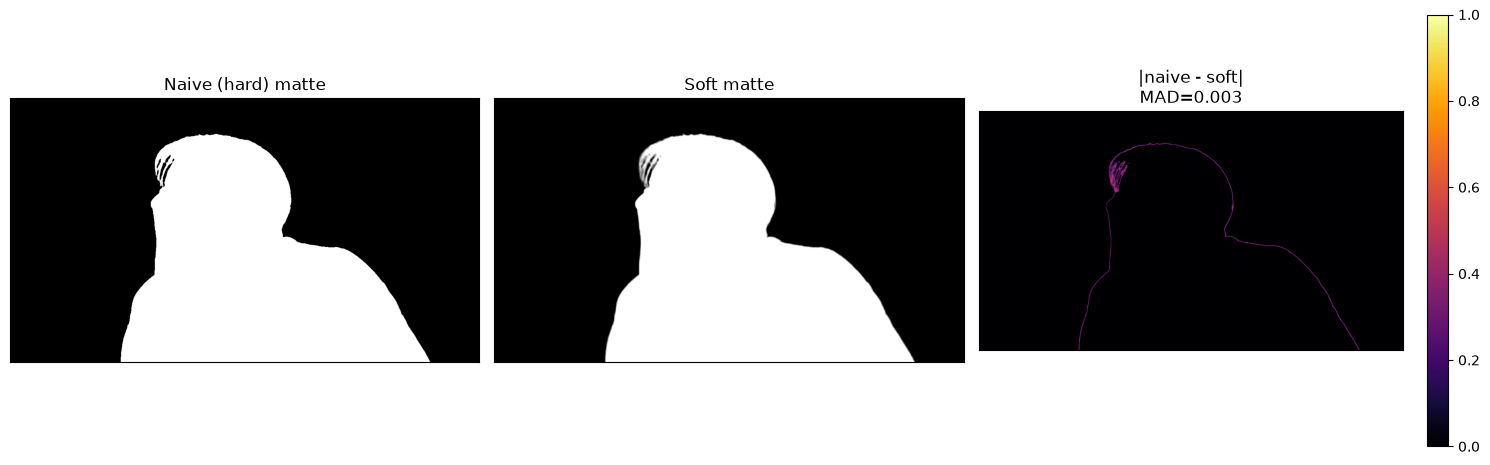

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
axes[0].imshow(alpha_naive, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Naive (hard) matte")
axes[1].imshow(alpha, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Soft matte")
diff = np.abs(alpha_naive - alpha)
im = axes[2].imshow(diff, cmap="inferno", vmin=0, vmax=1)
axes[2].set_title(f"|naive - soft|\nMAD={mad_alpha:.3f}")
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()